In [1]:
import os 
import matplotlib.pyplot as plt
import cv2 
import numpy as np
import sys 
sys.path.append("/home/abharadwaj1/thesis/5_vitrification/utils")
sys.path.append("/home/abharadwaj1/thesis/utils")
from video_utils import get_specific_frame

In [18]:
#video_path = "/home/abharadwaj1/thesis/data_archive/inputs/5_vitrification/analyse_cavity_closing/cryoemgrid/vid_2025-07-15_13-40-19.mp4"
prefix = ""
#video_path = "/home/abharadwaj1/thesis/data_archive/inputs/5_vitrification/impact_of_velocity_grids/vplunge_0p5/vid_2025-07-15_13-35-31.mp4"
#video_path = "/home/abharadwaj1/thesis/data_archive/inputs/5_vitrification/impact_of_velocity_grids/vplunge_1p5/vid_2025-07-15_13-44-23.mp4"
#video_path = "/home/abharadwaj1/thesis/data_archive/inputs/5_vitrification/impact_of_velocity_grids/vplunge_2/vid_2025-07-15_13-48-44.mp4"
#video_path = "/home/abharadwaj1/thesis/data_archive/inputs/5_vitrification/analyse_cavity_closing/autogrid/autogrid_front_vid_2025-07-21_19-28-45.mp4"
#video_path = "/home/abharadwaj1/thesis/data_archive/inputs/5_vitrification/analyse_cavity_closing/autogrid/autogrid_side_vid_2025-07-21_19-25-39.mp4"
#video_path = '/home/abharadwaj1/thesis/data_archive/inputs/5_vitrification/analyse_cavity_closing/cryochip/enhanced_videos/enhanced_video_cryochip_clip5_cryochip_front_vid_2025-07-21_19-30-54.mp4'
video_path = '/home/abharadwaj1/thesis/data_archive/inputs/5_vitrification/analyse_cavity_closing/cryochip/enhanced_videos/enhanced_video_cryochip_clip5_cryochip_side_vid_2025-07-21_19-32-18.mp4'
#video_path = "/home/abharadwaj1/thesis/data_archive/inputs/5_vitrification/analyse_cavity_closing/cryochip/enhanced_videos/enhanced_video_cryoemgrid_clip5_cryochip_front_vid_2025-07-21_19-30-54.mp4"
#video_path = "/home/abharadwaj1/thesis/data_archive/inputs/5_vitrification/analyse_cavity_closing/cryochip/enhanced_videos/enhanced_video_cryoemgrid_clip5_cryochip_side_vid_2025-07-21_19-32-18.mp4"
#video_path = "/home/abharadwaj1/thesis/data_archive/inputs/5_vitrification/analyse_cavity_closing/cryosilico/enhanced_videos/enhanced_video_cryosilico_clip5_newSiChip_front_vid_2025-07-21_19-08-45.mp4"
#video_path = "/home/abharadwaj1/thesis/data_archive/inputs/5_vitrification/analyse_cavity_closing/cryosilico/enhanced_videos/enhanced_video_cryosilico_clip5_newSiChip_side_vid_2025-07-21_19-02-35.mp4"
#video_path = "/home/abharadwaj1/thesis/data_archive/inputs/5_vitrification/analyse_cavity_closing/silicon_chip/enhanced_videos/enhanced_video_silicon_chip_clip5_oldSiChip_front_vid_2025-07-21_18-43-57.mp4"
#video_path = "/home/abharadwaj1/thesis/data_archive/inputs/5_vitrification/analyse_cavity_closing/silicon_chip/enhanced_videos/enhanced_video_silicon_chip_clip5_oldSiChip_side_vid_2025-07-21_18-39-26.mp4"
#video_path = "/home/abharadwaj1/thesis/data_archive/inputs/5_vitrification/analyse_cavity_closing/autogrid/enhanced_videos/enhanced_video_autogrid_clip5_autogrid_front_vid_2025-07-21_19-28-45.mp4"
#video_path = "/home/abharadwaj1/thesis/data_archive/inputs/5_vitrification/analyse_cavity_closing/autogrid/enhanced_videos/enhanced_video_autogrid_clip5_autogrid_side_vid_2025-07-21_19-25-39.mp4"
output_folder = "/home/abharadwaj1/thesis/data_archive/figures_output/5_vitrification/plot_plunging_process"
output_folder_video = os.path.join(output_folder, f"{prefix}_frames_{os.path.basename(video_path).split('.')[0]}")
if not os.path.exists(output_folder_video):
    os.makedirs(output_folder_video)

Text(0.5, 1.0, 'Last Frame')

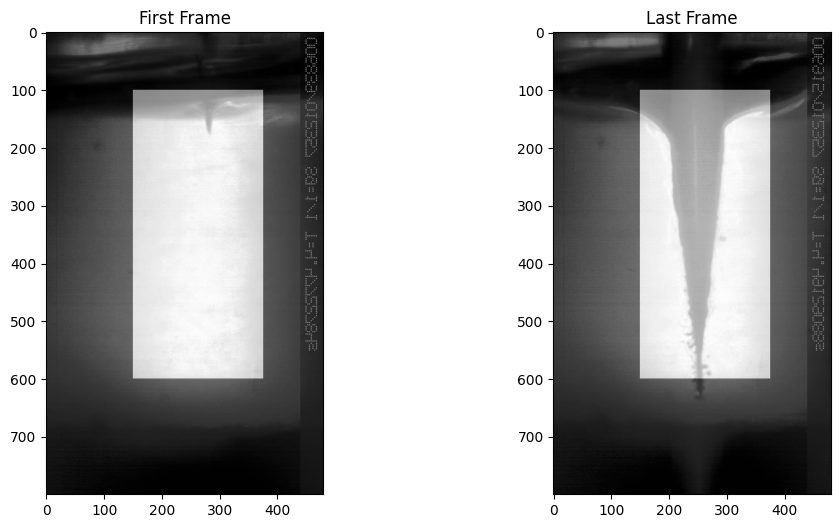

In [21]:
start_frame = 1#+ 10 + 10  # Adjusted start frame based on the provided logic
end_frame = start_frame + 76

first_frame = get_specific_frame(video_path, start_frame)
last_frame = get_specific_frame(video_path, end_frame).transpose()
first_frame = first_frame.transpose()
left_limit = 150
right_limit = left_limit + 175 + 50
top_limit = 100
bottom_limit = top_limit + 250 + 250
cropped_frame = first_frame[top_limit:bottom_limit, left_limit:right_limit]
mask = np.zeros_like(first_frame, dtype=np.uint8)
mask[top_limit:bottom_limit, left_limit:right_limit] = 1
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(first_frame, cmap='gray')
ax[0].imshow(mask, cmap='gray', alpha=0.5)
ax[0].set_title('First Frame')
#x[0].imshow(cropped_frame, cmap='gray', alpha=0.5)
ax[1].imshow(last_frame, cmap='gray')
ax[1].imshow(mask, cmap='gray', alpha=0.5)
ax[1].set_title('Last Frame')



#plt.imshow(mask, cmap='gray', alpha=0.5)
#plt.axis('off')

apix: 2.00e-05 m/pixel


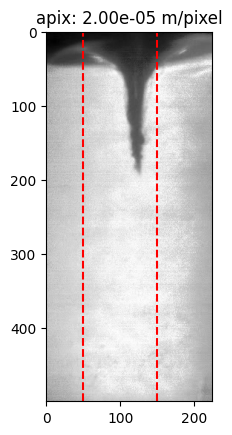

In [22]:
frame_rate = 5406 # in frames per second
left_limit_calibration = 50
right_limit_calibration = 150
reference_length = 2e-3 # in meters
apix = reference_length / (right_limit_calibration - left_limit_calibration) # in meters per pixel
calibration_frame_num = start_frame + 15  # Frame number for calibration
calibration_frame = get_specific_frame(video_path, calibration_frame_num).transpose()
cropped_calibration_frame = calibration_frame[top_limit:bottom_limit, left_limit:right_limit]
width = cropped_frame.shape[1]
height = cropped_frame.shape[0]
width_mm = width * apix * 1e3  # Convert to mm
height_mm = height * apix * 1e3  # Convert to mm

print(f"apix: {apix:.2e} m/pixel")
plt.title(f"apix: {apix:.2e} m/pixel")
plt.imshow(cropped_calibration_frame, cmap='gray')
plt.axvline(x=left_limit_calibration, color='red', linestyle='--')
plt.axvline(x=right_limit_calibration, color='red', linestyle='--')



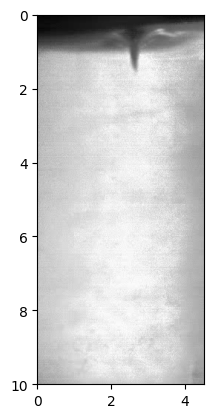

In [23]:
plt.imshow(cropped_frame, cmap='gray', extent=(0, width_mm, height_mm, 0))


In [17]:
# import rcparams
from matplotlib import rcParams
for i, frame_num in enumerate(range(start_frame, end_frame + 1)):
    # time in seconds
    sampling_time = i / frame_rate  
    
    # get and crop the frame
    frame = get_specific_frame(video_path, frame_num).transpose()
    cropped_frame = frame[top_limit:bottom_limit, left_limit:right_limit]
    height_cropped_frame = cropped_frame.shape[0]
    width_cropped_frame = cropped_frame.shape[1]
    # make timestamp (ms)
    time_stamp_ms = sampling_time * 1000
    time_stamp_text = f"{time_stamp_ms:.2f} ms"

    scale_bar_length = 1e-3  # in mm
    scale_bar_length_pixels = int(scale_bar_length / apix)
    
    # draw a scale bar on the cropped frame
    scale_bar_x_start = 120
    scale_bar_x_end = scale_bar_x_start + scale_bar_length_pixels
    scale_bar_y = height_cropped_frame - 40  # 20 pixels from the bottom
    cropped_frame[scale_bar_y:scale_bar_y+4, scale_bar_x_start:scale_bar_x_end] = 0  # white line for scale bar
    # plot the frame
    plt.figure(figsize=(6, 6))
    rcParams['pdf.fonttype'] = 42  # Use Type 42 for better compatibility
    plt.imshow(cropped_frame, cmap="gray")
    plt.axis("off")
    # draw the scale bar using plt
    #plt.hlines(220, 150, scale_bar_length_pixels, color="red", linewidth=2)

    # annotate in data coordinates (x,y are pixel indices)
    plt.text(20, 10, time_stamp_text,
             color="white", fontsize=14,
             ha="left", va="top")
    # add a scale bar for 1mm
    
    # save as PDF
    output_path = os.path.join(output_folder_video, f"frame_{frame_num:04d}.pdf")
    plt.savefig(output_path, bbox_inches="tight", pad_inches=0)
    plt.close()